In [1]:
import numpy as np
from scipy.optimize import linprog
import pandas as pd
import pulp
import networkx as nx
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from joblib import Parallel, delayed

## 1. Récupération des données

### a. Chargement des données pour 1 pays du code jouet

In [2]:
# Chargement des données
df_solar = pd.read_csv('solar.csv')
df_wind = pd.read_csv('wind_onshore.csv')
df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]

# Calcul consommation annuelle
annual_demand = df_demand['demande'].sum()

# Calcul production potentielle pour 1GW installé
annual_solar_per_gw = df_solar['facteur_charge'].sum()
annual_wind_per_gw = df_wind['facteur_charge'].sum()

# Pour avoir 100% de surproduction et un mix 50-50
target_production = annual_demand * 3.5
wind_capacity = target_production/(2 * annual_wind_per_gw)
solar_capacity = target_production/(2 * annual_solar_per_gw)

print(f"Capacités requises: éolien = {wind_capacity:.1f}GW, solaire = {solar_capacity:.1f}GW")

Capacités requises: éolien = 297.6GW, solaire = 539.7GW


### b. Tranformation pour simuler 5 pays différents

In [3]:
T = len(df_demand)
N=5

assert T % N == 0, "T doit être divisible par N"

demand_1 = df_demand['demande'].values*2.5 # shape (T,)
demand_N = demand_1.reshape(N, T // N)

solar_1 = df_solar['facteur_charge'].values
solar_N = solar_1.reshape(N, T // N)

wind_1  = df_wind['facteur_charge'].values
wind_N  = wind_1.reshape(N, T // N)

demand_N = demand_N.T    # shape (T/N, N)
solar_N  = solar_N.T
wind_N   = wind_N.T

wind_cap_N  = np.full(N, wind_capacity)
solar_cap_N = np.full(N, solar_capacity)

### c. Chargement des valeurs d'échange maximales

In [4]:
qmax11pays = np.array([[0 ,50,20,30,40,70,20,30,50,40,70],
                       [50,0 ,80,40,30,20,50,0 ,70,60,30],
                       [20,80,0 ,60,50,60,40,30,70,50,20],
                       [30,40,60,0 ,40,60,0 ,40,60,0 ,40],
                       [40,30,50,40,0 ,40,30,70,60,80,70],
                       [70,20,60,60,40,0 ,20,30,20,60,60],
                       [20,50,40,0 ,30,20,0 ,40,50,60,40],
                       [30,0 ,30,40,70,30,40,0 ,30,70,50],
                       [50,70,70,60,60,20,50,30,0 ,30,60],
                       [40,60,50,0 ,80,60,60,70,30,0 ,30],
                       [70,30,20,40,70,60,40,50,60,30,0 ]])

qmax = qmax11pays[:N,:N]

## 2. Définition du problème

## a. Code optimisation stockage 1 pays

In [5]:
def optimize_storage(prod, demand,
                    phs_capacity, phs_power, phs_eff,
                    ptg_capacity, ptg_power_in, ptg_power_out, 
                    ptg_eff, penalisation):
    """
    Optimise la stratégie de stockage sur l'année avec contrainte cyclique
    
    Parameters:
    -----------
    solar_profile, wind_profile: séries temporelles des facteurs de charge
    demand: série temporelle de la demande
    wind_cap, solar_cap: capacités installées en GW
    phs_capacity: capacité de stockage PHS en GWh
    phs_power: puissance max PHS en GW
    phs_eff: rendement PHS (aller-retour)
    ptg_capacity: capacité de stockage P2G en GWh
    ptg_power_in: puissance max électrolyse en GW  
    ptg_power_out: puissance max reconversion en GW
    ptg_eff: rendement P2G (aller-retour)
    """
    
    T = len(demand)  # nombre d'heures
    
    # Création du problème
    prob = pulp.LpProblem("Storage_Strategy", pulp.LpMinimize)
    
    # Variables
    phs_in = pulp.LpVariable.dicts("phs_in", range(T), 0)  # Charge PHS
    phs_out = pulp.LpVariable.dicts("phs_out", range(T), 0)  # Décharge PHS
    phs_level = pulp.LpVariable.dicts("phs_level", range(T), 0)  # Niveau PHS
    
    ptg_in = pulp.LpVariable.dicts("ptg_in", range(T), 0)  # Charge P2G
    ptg_out = pulp.LpVariable.dicts("ptg_out", range(T), 0)  # Décharge P2G
    ptg_level = pulp.LpVariable.dicts("ptg_level", range(T), 0)  # Niveau P2G
    
    deficit = pulp.LpVariable.dicts("deficit", range(T), 0)  # Déficit
    surplus = pulp.LpVariable.dicts("surplus", range(T), lowBound=0) # Surplus

    
    # Fonction objectif : minimiser déficits
    prob += -ptg_level[T-1] + penalisation * pulp.lpSum(deficit[t] for t in range(T))
    
    # Contraintes
    
    # Niveaux initiaux
    prob += phs_level[0] == phs_capacity/2  # PHS à 50%
    prob += ptg_level[0] == ptg_capacity    # P2G plein
    
    # Contraintes cycliques : les niveaux finaux doivent être égaux aux niveaux initiaux
    #prob += phs_level[T-1] == phs_level[0]
    #prob += ptg_level[T-1] == ptg_level[0]
    
    for t in range(T):
        # Équilibre offre-demande
        prob += (
                prod[t] 
                + phs_out[t] * phs_eff 
                + ptg_out[t] * ptg_eff 
                + deficit[t]
                == 
                demand[t] 
                + phs_in[t] 
                + ptg_in[t]
                + surplus[t]
        )
        
        # Limites PHS
        prob += phs_in[t] <= phs_power
        prob += phs_out[t] <= phs_power
        prob += phs_level[t] <= phs_capacity
        
        # Limites P2G
        prob += ptg_in[t] <= ptg_power_in
        prob += ptg_out[t] <= ptg_power_out
        prob += ptg_level[t] <= ptg_capacity
        
        # Évolution des stocks
        if t > 0:
            prob += phs_level[t] == phs_level[t-1] + phs_in[t]*phs_eff - phs_out[t]
            prob += ptg_level[t] == ptg_level[t-1] + ptg_in[t]*ptg_eff - ptg_out[t]
       
        
    # Résolution
    prob.solve()
    
    return {
        'status': pulp.LpStatus[prob.status],
        'prod':prod,
        'phs_in': [phs_in[t].value() for t in range(T)],
        'phs_out': [phs_out[t].value() for t in range(T)],
        'phs_level': [phs_level[t].value() for t in range(T)],
        'ptg_in': [ptg_in[t].value() for t in range(T)],
        'ptg_out': [ptg_out[t].value() for t in range(T)],
        'ptg_level': [ptg_level[t].value() for t in range(T)],
        'deficit': [deficit[t].value() for t in range(T)],
        'surplus': [surplus[t].value() for t in range(T)]
    }


## b. Code optimisation des échanges n pays

In [6]:
def solve_flux(surplus, deficit, qmax_matrix, flux_eff, penalisation):
    """
    Résout le flux optimal pour N pays et T périodes, avec PuLP.

    surplus : np.array (T, N)
    deficit : np.array (T, N)
    qmax_matrix : np.array (N, N), symétrique, diag = 0
    """

    T, N = surplus.shape

    # Sécurité : contrôle taille qmax_matrix
    assert qmax_matrix.shape == (N, N), "qmax_matrix doit être de taille (N, N)"
    assert np.allclose(qmax_matrix, qmax_matrix.T), "qmax_matrix doit être symétrique"
    assert np.all(np.diag(qmax_matrix) == 0), "La diagonale de qmax_matrix doit être nulle"

    Q = surplus - deficit

    # Problème d'optimisation
    prob = pulp.LpProblem("Optimal_Flux", pulp.LpMinimize)

    # Flux inter-pays q[t,i,j]
    q = {}
    for t in range(T):
        for i in range(N):
            for j in range(N):
                if i != j:
                    q[t, i, j] = pulp.LpVariable(
                        f"q_{t}_{i}_{j}",
                        lowBound=0,
                        upBound=float(qmax_matrix[i, j])
                    )

    # Variables r_pos et r_neg
    r_pos, r_neg = {}, {}
    for t in range(T):
        for i in range(N):
            if Q[t, i] >= 0:
                r_pos[t, i] = pulp.LpVariable(f"r_pos_{t}_{i}", lowBound=0)
                r_neg[t, i] = pulp.LpVariable(f"r_neg_{t}_{i}", lowBound=0, upBound=0)
            else:
                r_pos[t, i] = pulp.LpVariable(f"r_pos_{t}_{i}", lowBound=0, upBound=0)
                r_neg[t, i] = pulp.LpVariable(f"r_neg_{t}_{i}", lowBound=0)

    # Fonction objectif : minimiser les déficites et maximiser les restes positifs
    prob += pulp.lpSum(penalisation*r_neg[t, i]-r_pos[t, i] for t in range(T) for i in range(N))

    # Contraintes de bilan
    for t in range(T):
        for i in range(N):
            inflow = pulp.lpSum(q[t, j, i] for j in range(N) if j != i)
            outflow = pulp.lpSum(q[t, i, j] for j in range(N) if j != i)
            prob += (
                r_pos[t, i] - r_neg[t, i]
                == surplus[t, i] - deficit[t, i] + flux_eff * inflow - outflow
            )

    # Résolution
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # Extraction solutions
    q_array = np.zeros((T, N, N))
    new_surplus = np.zeros((T, N))
    new_deficit= np.zeros((T, N))

    for t in range(T):
        for i in range(N):
            new_surplus[t, i] = pulp.value(r_pos[t, i])
            new_deficit[t, i] = pulp.value(r_neg[t, i])
            for j in range(N):
                if i != j:
                    q_array[t, i, j] = pulp.value(q[t, i, j])

    return {
        'echanges' : q_array,
        'surplus' : new_surplus,
        'deficit' : new_deficit
    }


## c. Combiner les deux optimisations

In [7]:
def optimize(
    wind_profile, solar_profile, demand,
    wind_cap, solar_cap, qmax_matrix,
    phs_capacity=180, phs_power=9.3, phs_eff=0.75,
    ptg_capacity=125000, ptg_power_in=7.66, ptg_power_out=32.93,
    ptg_eff=0.4, penalisation=1e10, flux_eff=0.9
):

    T, N = demand.shape
    
    # 1 - Calcul de la production
    
    prod = (
        wind_cap * wind_profile
        + solar_cap * solar_profile
    )
    
    # 2 - Calculs des échanges 

    result1=solve_flux(prod, demand, qmax_matrix, flux_eff, penalisation)
    
    echanges=result1['echanges']
    surplus_avant=result1['surplus']
    deficit_avant=result1['deficit']
    
    # 3 - Optimisation du stockage pour chaque pays en parralèle
    
    def run_one_country(p):
        return optimize_storage(
            surplus_avant[:, p], deficit_avant[:, p], phs_capacity, phs_power, phs_eff, 
            ptg_capacity, ptg_power_in, ptg_power_out, ptg_eff, penalisation
        )

    result2 = Parallel(n_jobs=-1)(delayed(run_one_country)(p) for p in range(N))

    phs_in, phs_out, phs_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    ptg_in, ptg_out, ptg_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    deficit, surplus = np.zeros((T, N)), np.zeros((T, N))

    # 4 - Rassemblement des résultats
    for p, res in enumerate(result2):
        phs_in[:, p] = res['phs_in']
        phs_out[:, p] = res['phs_out']
        phs_level[:, p] = res['phs_level']
        ptg_in[:, p] = res['ptg_in']
        ptg_out[:, p] = res['ptg_out']
        ptg_level[:, p] = res['ptg_level']
        deficit[:, p] = res['deficit']
        surplus[:, p] = res['surplus']


    return {
        
        'prod' : prod,
        
        'phs_in': phs_in,
        'phs_out': phs_out,
        'phs_level': phs_level,

        'ptg_in': ptg_in,
        'ptg_out': ptg_out,
        'ptg_level': ptg_level,
        
        'deficit avant echange' : deficit_avant,
        'surplus avant echange' : surplus_avant,

        'deficit': deficit,
        'surplus': surplus,

        'Echanges': echanges
    }
    
    

## 3. Execution de l'optimisation

In [8]:
result = optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3, #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=100*7.66, #modifié en faisant 100*
    ptg_power_out=2*32.93,  #modifié en faisant 2*
    ptg_eff=0.4,
    penalisation=1e10,
    flux_eff=0.9
)

## 4. Interprétation graphique

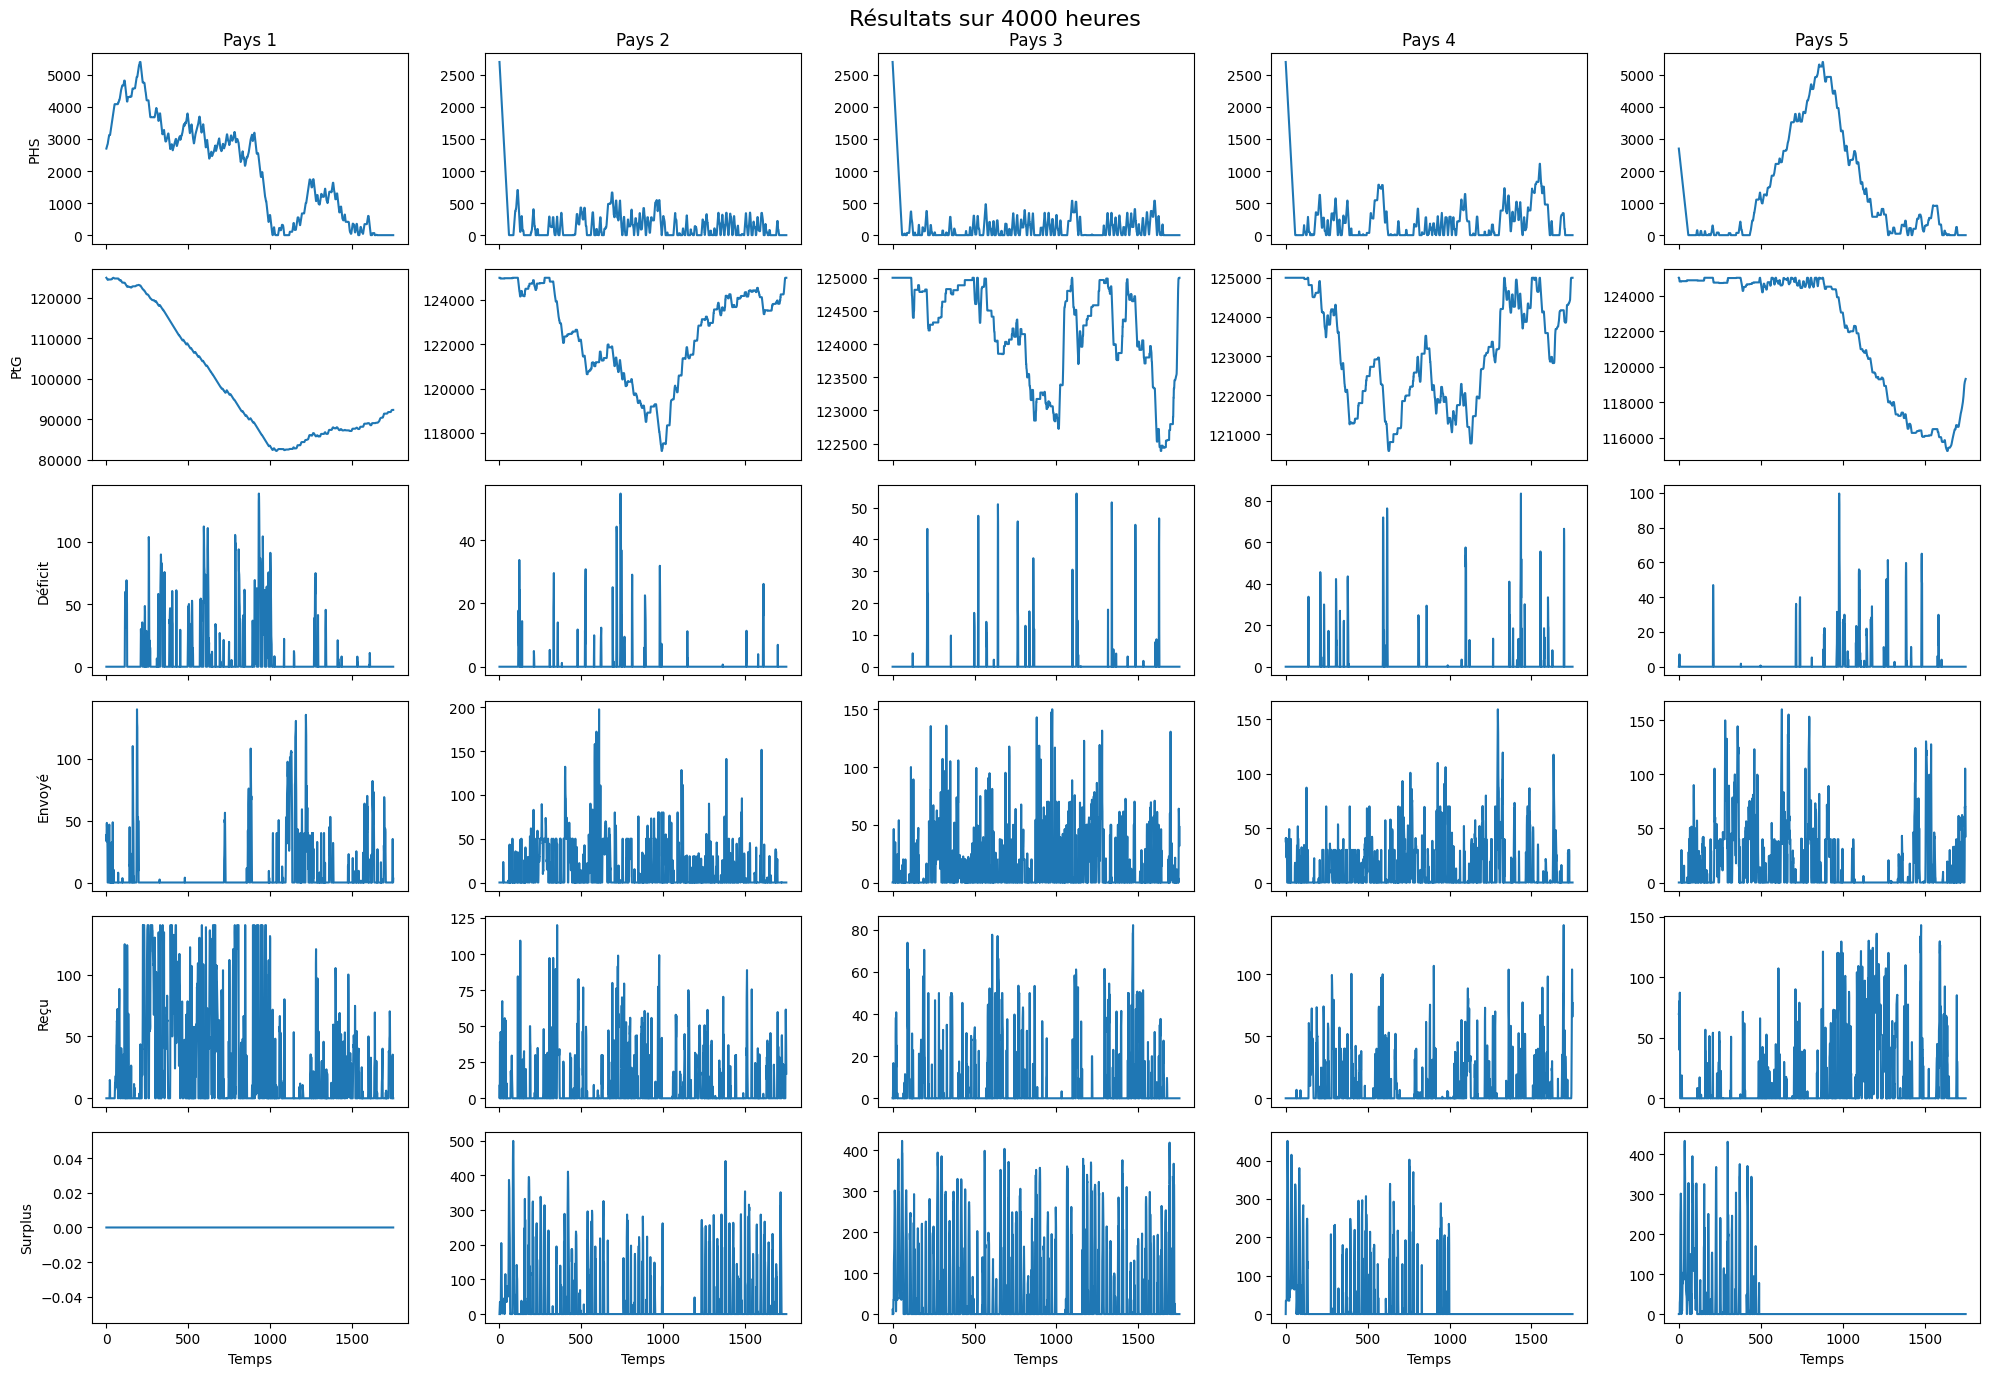

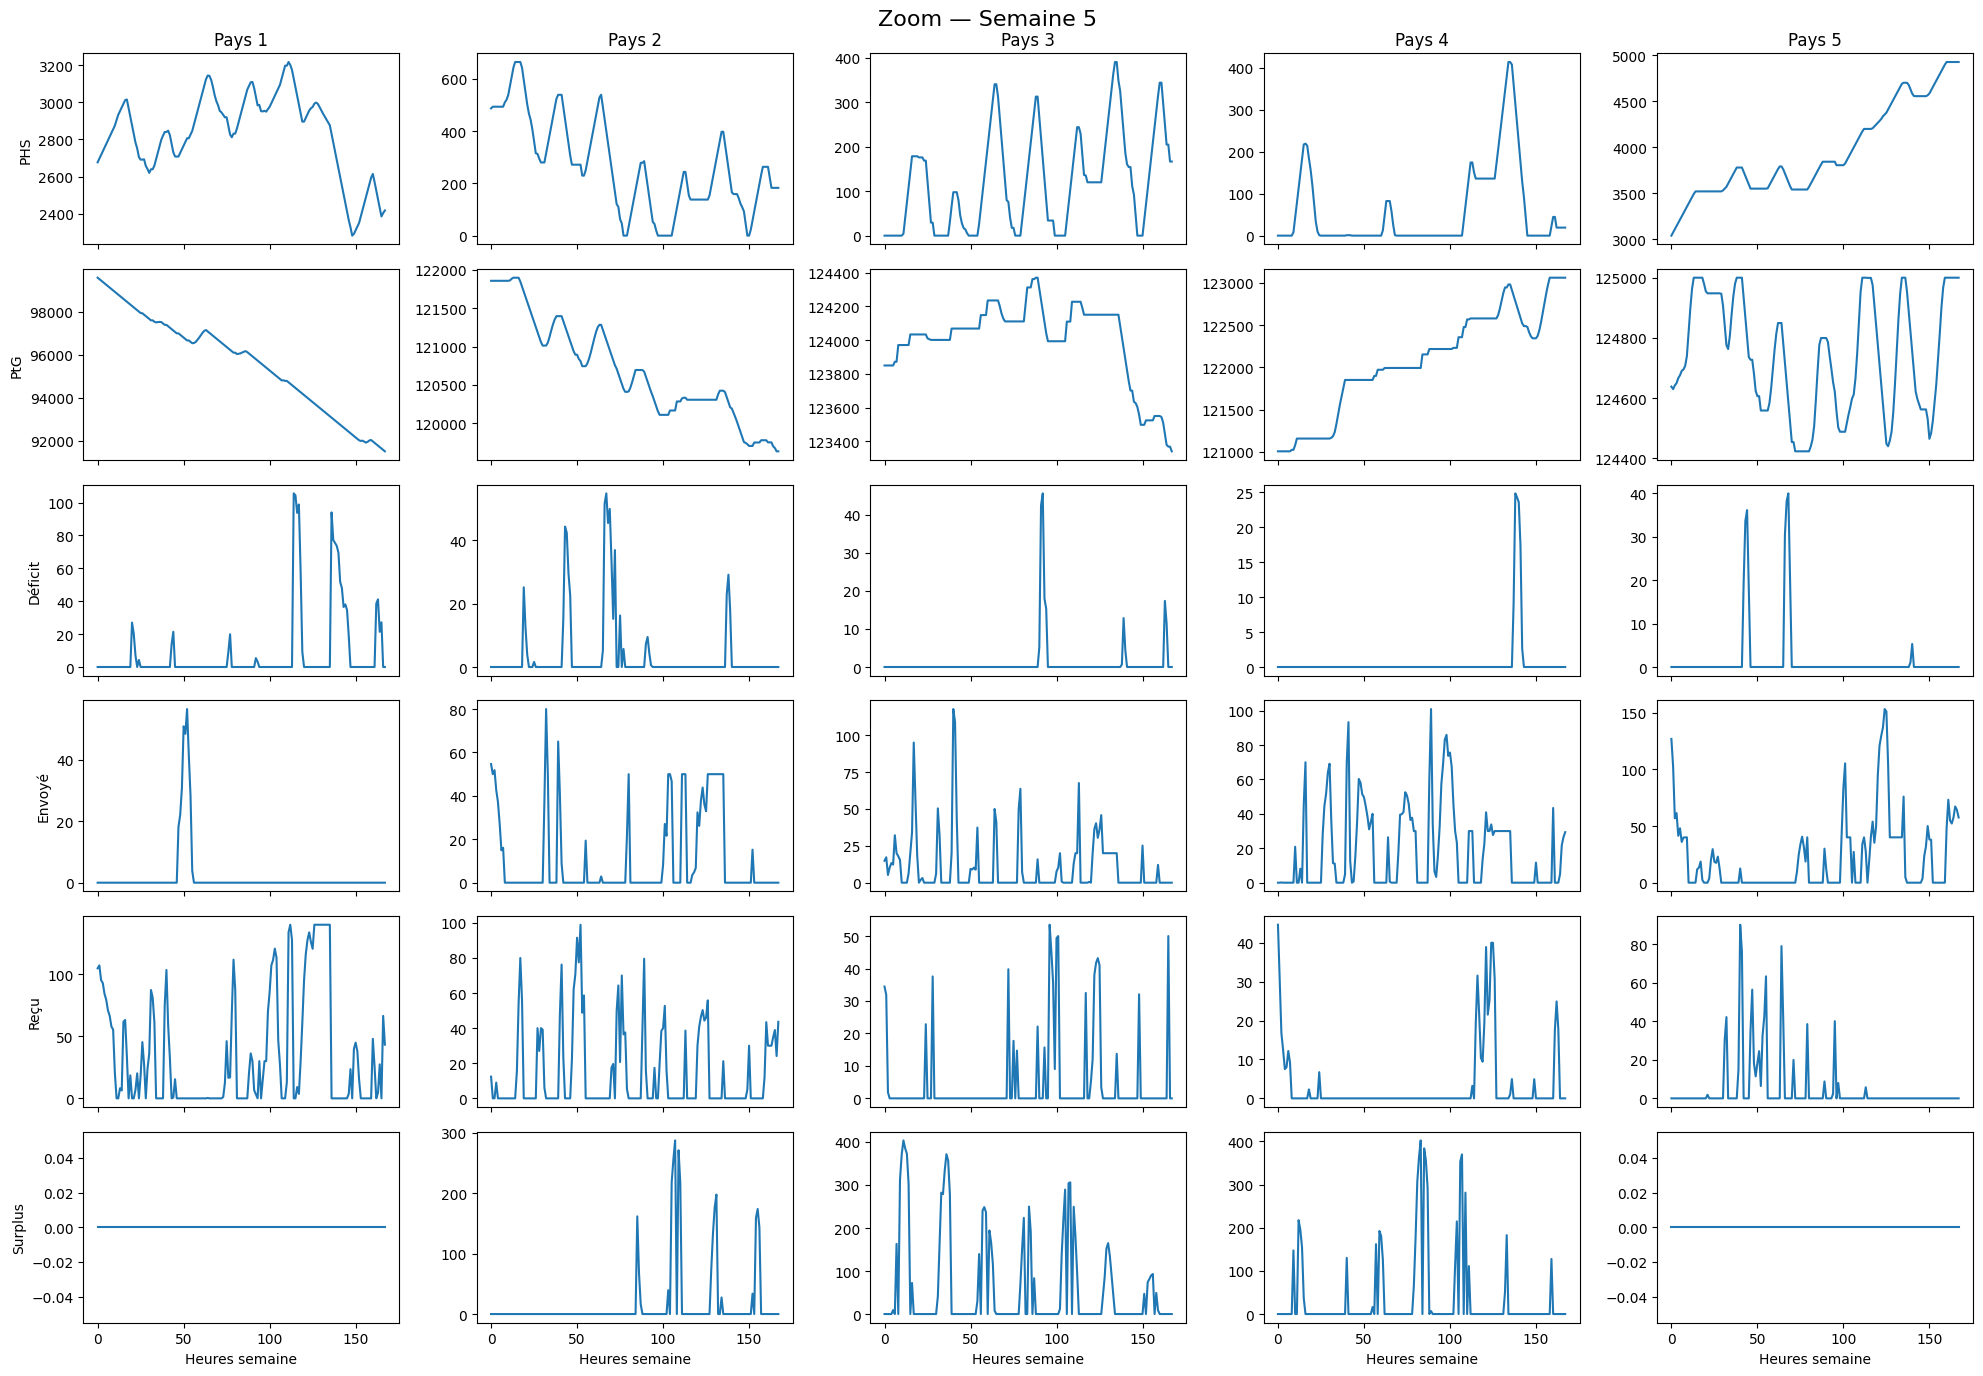

In [19]:
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["Echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (4000 heures)
# =====================================================
T_plot = 4000

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][:T_plot, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][:T_plot, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][:T_plot, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[:T_plot, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[:T_plot, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")

    axes[5, i].plot(result['surplus'][:T_plot, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Temps")

plt.suptitle("Résultats sur 4000 heures", fontsize=16)
plt.tight_layout()
plt.show()


# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 5
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][T0:T1, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][T0:T1, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][T0:T1, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[T0:T1, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")
    
    axes[5, i].plot(result['surplus'][T0:T1, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Heures semaine")

plt.suptitle(f"Zoom — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()


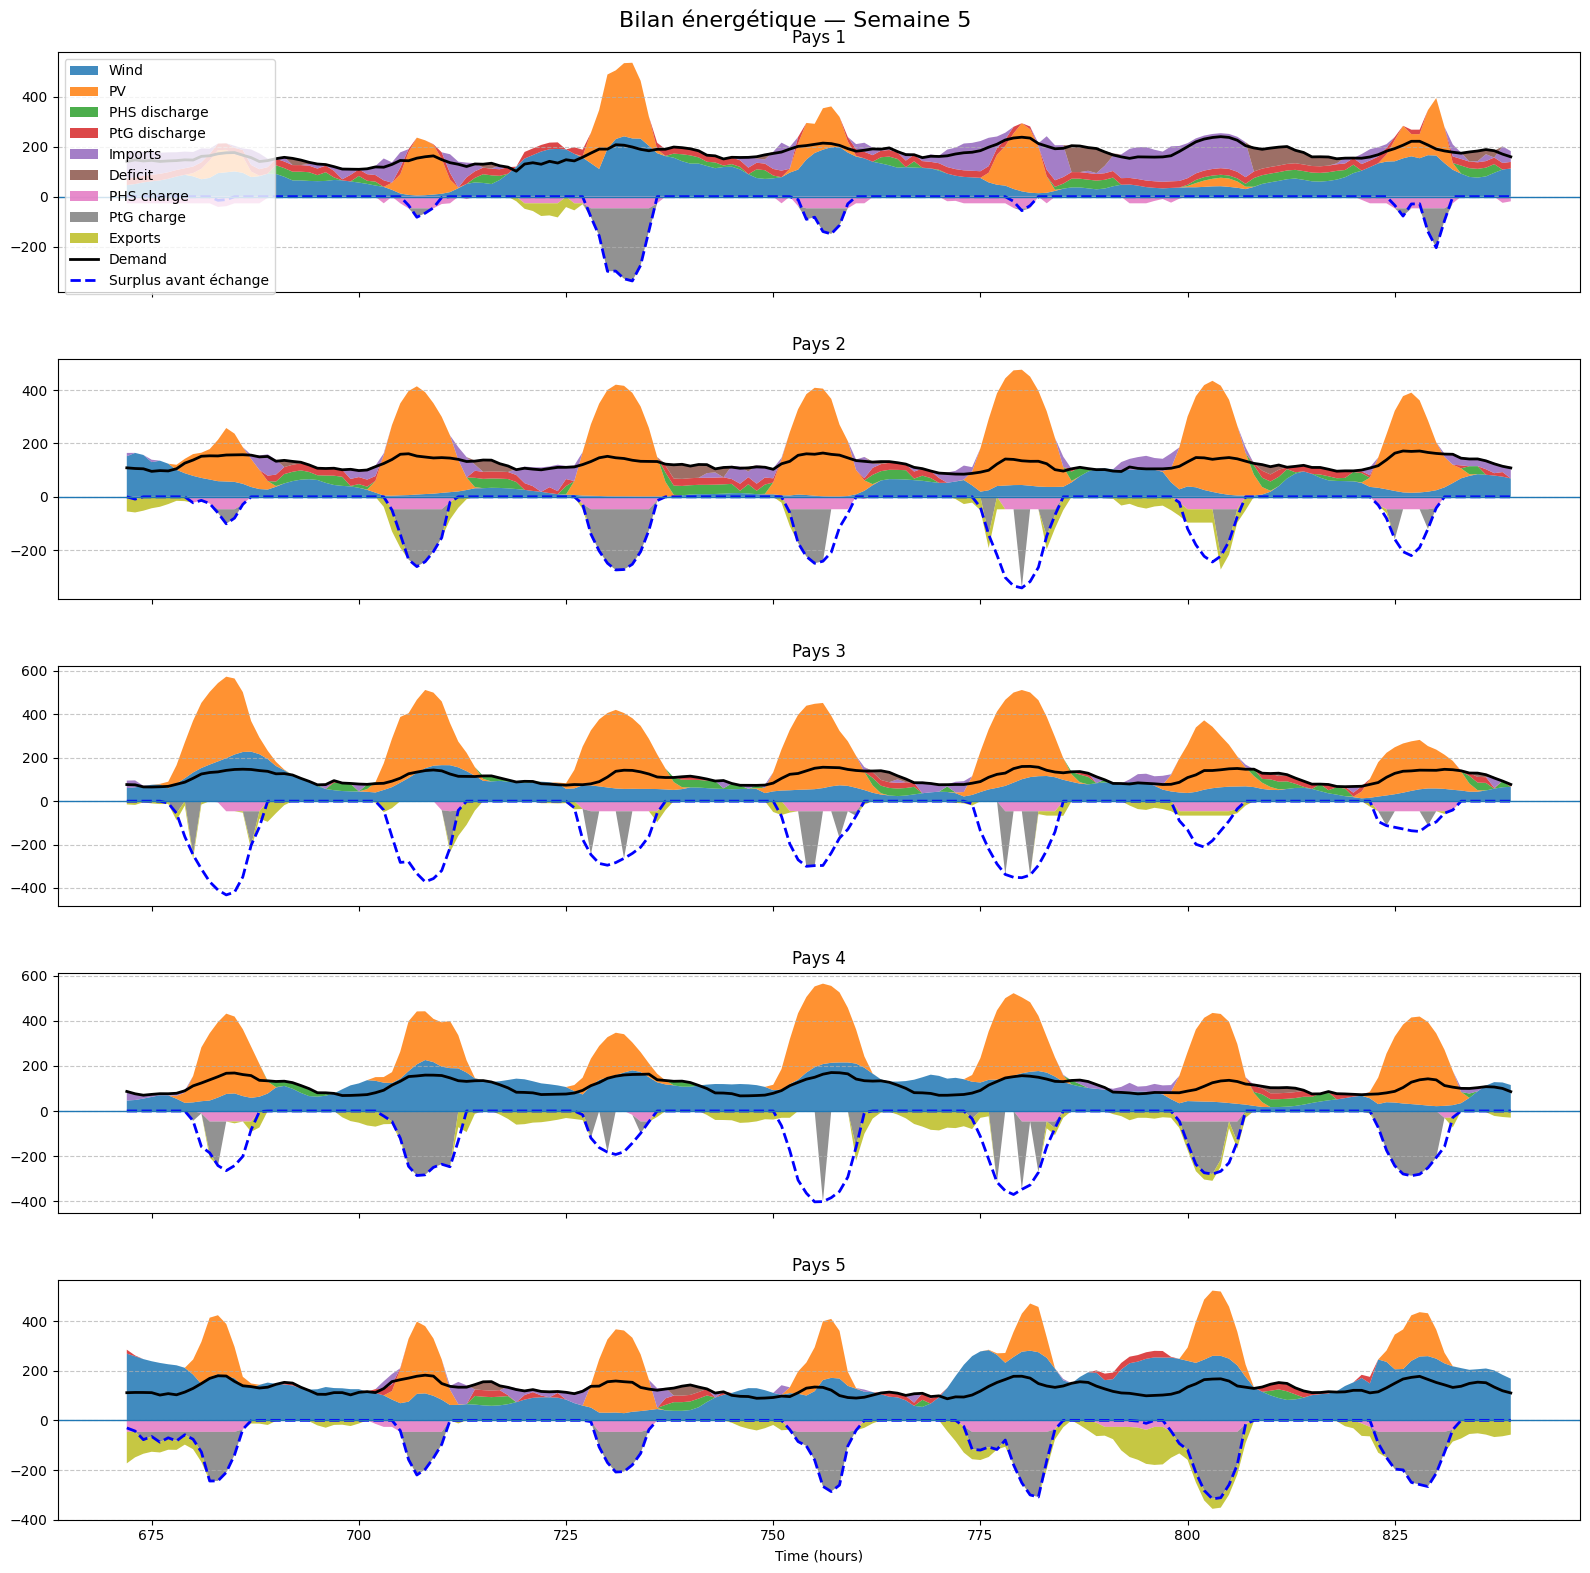

In [26]:
# ===============================
# Flux échanges
# ===============================

ptg_eff = 0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Surplus avant échange (négatif) ---
    surplus_i = -result["surplus avant echange"][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')
    
    # --- Surplus ---
    axes[i].plot(time_axis,
                 surplus_i,
                 color='blue',
                 linewidth=2,
                 linestyle='--',
                 label='Surplus avant échange')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports', 'Demand', 'Surplus avant échange'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
def compute_static_pos(qmax_matrix):
    N = qmax_matrix.shape[0]
    G = nx.DiGraph()

    # Création structure graphique
    for i in range(N):
        G.add_node(i)
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G.add_edge(i, j)

    return nx.spring_layout(G, seed=42)


def show_graphs(prod_matrix, demand_matrix, qmax_matrix,
                q_array, r_pos_array, r_neg_array,
                pos, period=0):

    T, N = prod_matrix.shape

    # ===== Graphe Capacités qmax =====
    G1 = nx.DiGraph()
    Q = prod_matrix[period] - demand_matrix[period]

    for i in range(N):
        G1.add_node(i, Q=Q[i])
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G1.add_edge(i, j, qmax=qmax_matrix[i, j])

    node_colors1 = ["#6BC729" if Q[i] >= 0 else "#F77260" for i in G1.nodes()]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Taille des arêtes FIXE
    nx.draw(G1, pos, ax=axes[0], node_color=node_colors1,
            node_size=4500, width=2, edge_color="#7D7D7D",
            arrowsize=20)

    # Labels noeuds
    labels1 = {i: f"P{i}\nQ={Q[i]:.1f}" for i in G1.nodes()}
    nx.draw_networkx_labels(
        G1, pos,
        labels=labels1,
        font_size=13,
        font_weight="bold",
        ax=axes[0]
    )

    # Labels arêtes qmax
    edge_labels1 = {(i, j): f"{G1.edges[i, j]['qmax']:.1f}" for i, j in G1.edges()}
    nx.draw_networkx_edge_labels(
        G1, pos,
        edge_labels=edge_labels1,
        font_size=15,
        font_weight="bold",
        ax=axes[0]
    )

    axes[0].set_title(f"Capacités qmax - Période {period}")


    # ===== Graphe flux réels =====
    G2 = nx.DiGraph()
    for i in range(N):
        r = r_pos_array[period, i] - r_neg_array[period, i]
        G2.add_node(i, r=r)
    for i in range(N):
        for j in range(N):
            v = q_array[period, i, j]
            if i != j and v > 1e-6:
                G2.add_edge(i, j, flux=v)

    node_colors2 = ['#6BC729' if G2.nodes[i]['r'] >= 0 else "#F77260" for i in G2.nodes()]
    nx.draw(G2, pos, ax=axes[1], node_color=node_colors2,
            node_size=4500, width=2,
            edge_color="#337FEA", arrowsize=20)

    labels2 = {i: f"P{i}\nr={G2.nodes[i]['r']:.2f}" for i in G2.nodes()}
    nx.draw_networkx_labels(
        G2, pos,
        labels=labels2,
        font_size=13,
        font_weight="bold",
        ax=axes[1]
    )

    # Labels arêtes flux
    edge_labels2 = {(i, j): f"{G2.edges[i, j]['flux']:.2f}" for i, j in G2.edges()}
    nx.draw_networkx_edge_labels(
        G2, pos,
        edge_labels=edge_labels2,
        font_size=15,
        font_weight="bold",
        ax=axes[1]
    )


    axes[1].set_title("Flux optimisés")

    plt.show()



# === Fonction interactive finale ===
def interactive_graphs(prod, dem, qmax, q, r_pos, r_neg):
    pos = compute_static_pos(qmax)
    T = prod.shape[0]

    interact(lambda period: show_graphs(prod, dem, qmax, q, r_pos, r_neg, pos, period),
             period=IntSlider(min=0, max=T-1, step=1, value=0, description="Temps"))

In [12]:
interactive_graphs(result['surplus avant echange'], result['deficit avant echange'], qmax, q, result['surplus'], result['deficit'])

interactive(children=(IntSlider(value=0, description='Temps', max=1751), Output()), _dom_classes=('widget-inte…